In [ ]:
# 0: Kütüphaneler
!pip install xarray netcdf4 scipy --quiet

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

print("✓ Tüm kütüphaneler yüklendi")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.9 MB/s eta 0:00:00
✓ Tüm kütüphaneler yüklendi


In [ ]:
# 0-1: Veri

ds = xr.open_dataset('ERA5_Barents_Sea.nc')
print(ds)

<xarray.Dataset> Size: 6MB
Dimensions:     (valid_time: 5844, latitude: 5, longitude: 17)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 47kB 2000-01-01T12:00:00 ... 2015...
  * latitude    (latitude) float64 40B 75.0 74.75 74.5 74.25 74.0
  * longitude   (longitude) float64 136B 36.0 36.25 36.5 ... 39.5 39.75 40.0
    number      int64 8B ...
    expver      (valid_time) <U4 94kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB ...
    sst         (valid_time, latitude, longitude) float32 2MB ...
    siconc      (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-17T18:17 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
# 1: Zaman serisi
t2m = ds['t2m'].mean(dim=['latitude','longitude'])
sst = ds['sst'].mean(dim=['latitude','longitude'])
sic = ds['siconc'].mean(dim=['latitude','longitude'])

time = pd.to_datetime(ds['valid_time'].values)

t2m_c = t2m.values - 273.15
sst_c = sst.values - 273.15
sic_v = sic.values

df = pd.DataFrame({'t2m': t2m_c, 'sst': sst_c, 'sic': sic_v}, index=time)
df['month'] = df.index.month
df['year']  = df.index.year

ay_isimleri = ['Oca','Şub','Mar','Nis','May','Haz',
               'Tem','Ağu','Eyl','Eki','Kas','Ara']

vars_plot = [('t2m', 'T2m (°C)',              '#2196F3'),
             ('sst', 'SST (°C)',              '#FF5722'),
             ('sic', 'Sea Ice Concentration', '#4CAF50')]

print(df.describe())
print(f"\nZaman: {time[0].date()} → {time[-1].date()}, N={len(df)}")

               t2m          sst          sic        month         year
count  5844.000000  5844.000000  5844.000000  5844.000000  5844.000000
mean     -0.097847     2.088654     0.027138     6.522930  2007.498973
std       4.625494     2.093588     0.127437     3.448998     4.610241
min     -25.836258    -1.689972     0.000000     1.000000  2000.000000
25%      -2.607323     0.500534     0.000000     4.000000  2003.750000
50%       0.532471     1.563431     0.000000     7.000000  2007.500000
75%       3.178925     3.666252     0.000000    10.000000  2011.250000
max      10.375061     8.687561     0.931310    12.000000  2015.000000

Zaman: 2000-01-01 → 2015-12-31, N=5844


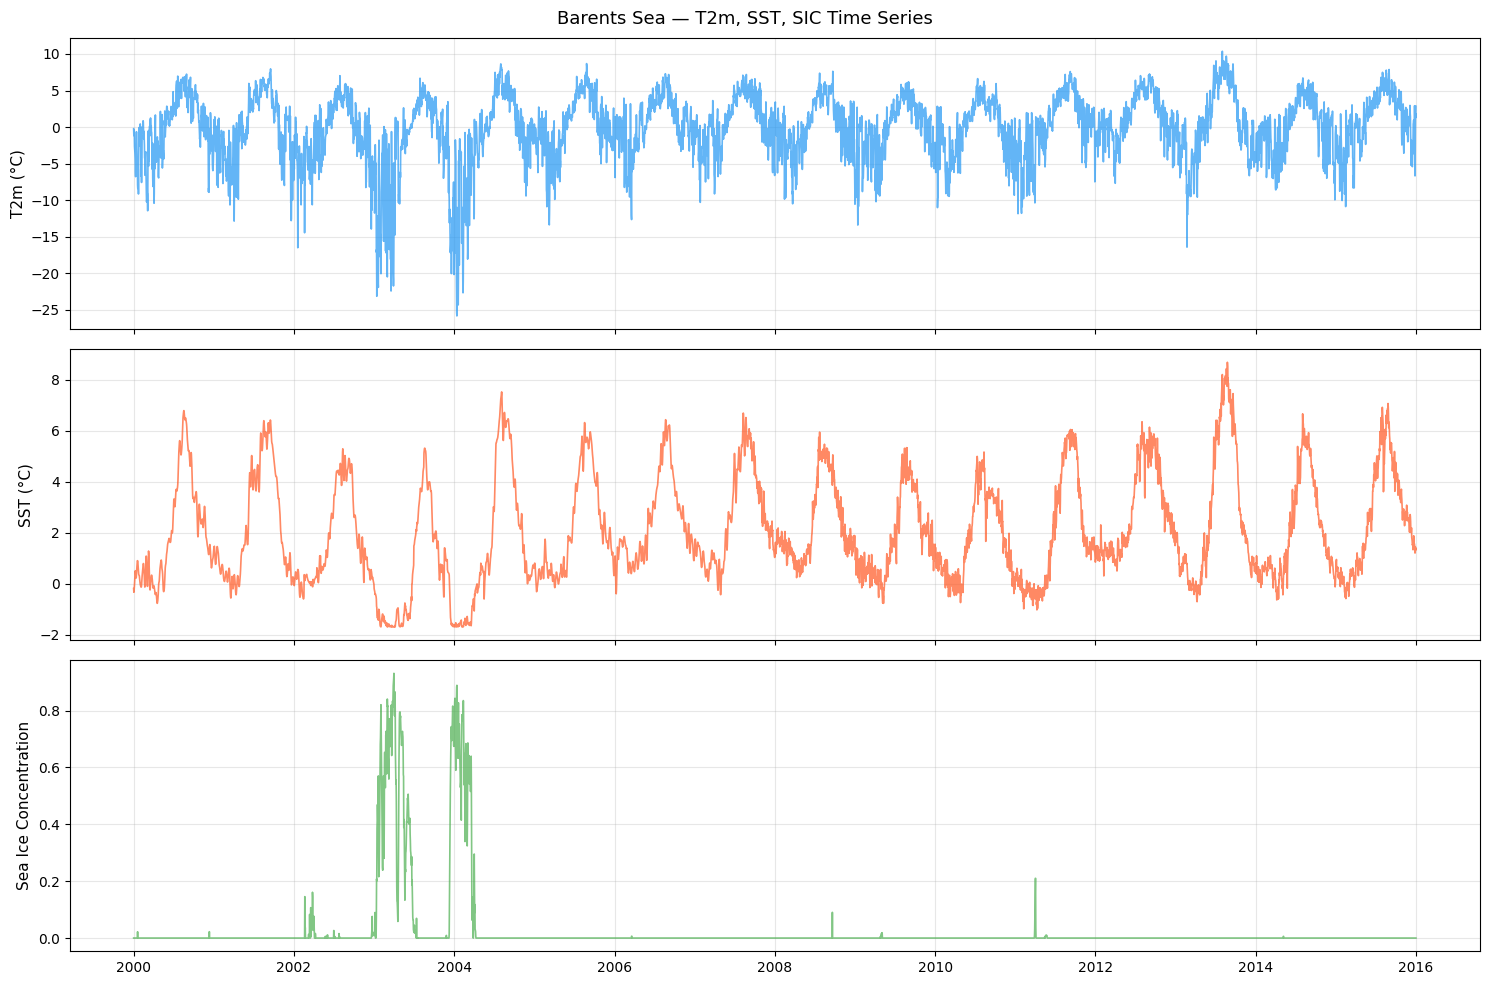

In [ ]:
# 2: Zaman serisi
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for ax, (col, label, color) in zip(axes, vars_plot):
    ax.plot(df.index, df[col], color=color, lw=1.2, alpha=0.7)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle('Barents Sea — T2m, SST, SIC Time Series', fontsize=13)
plt.tight_layout()
plt.savefig('01a_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

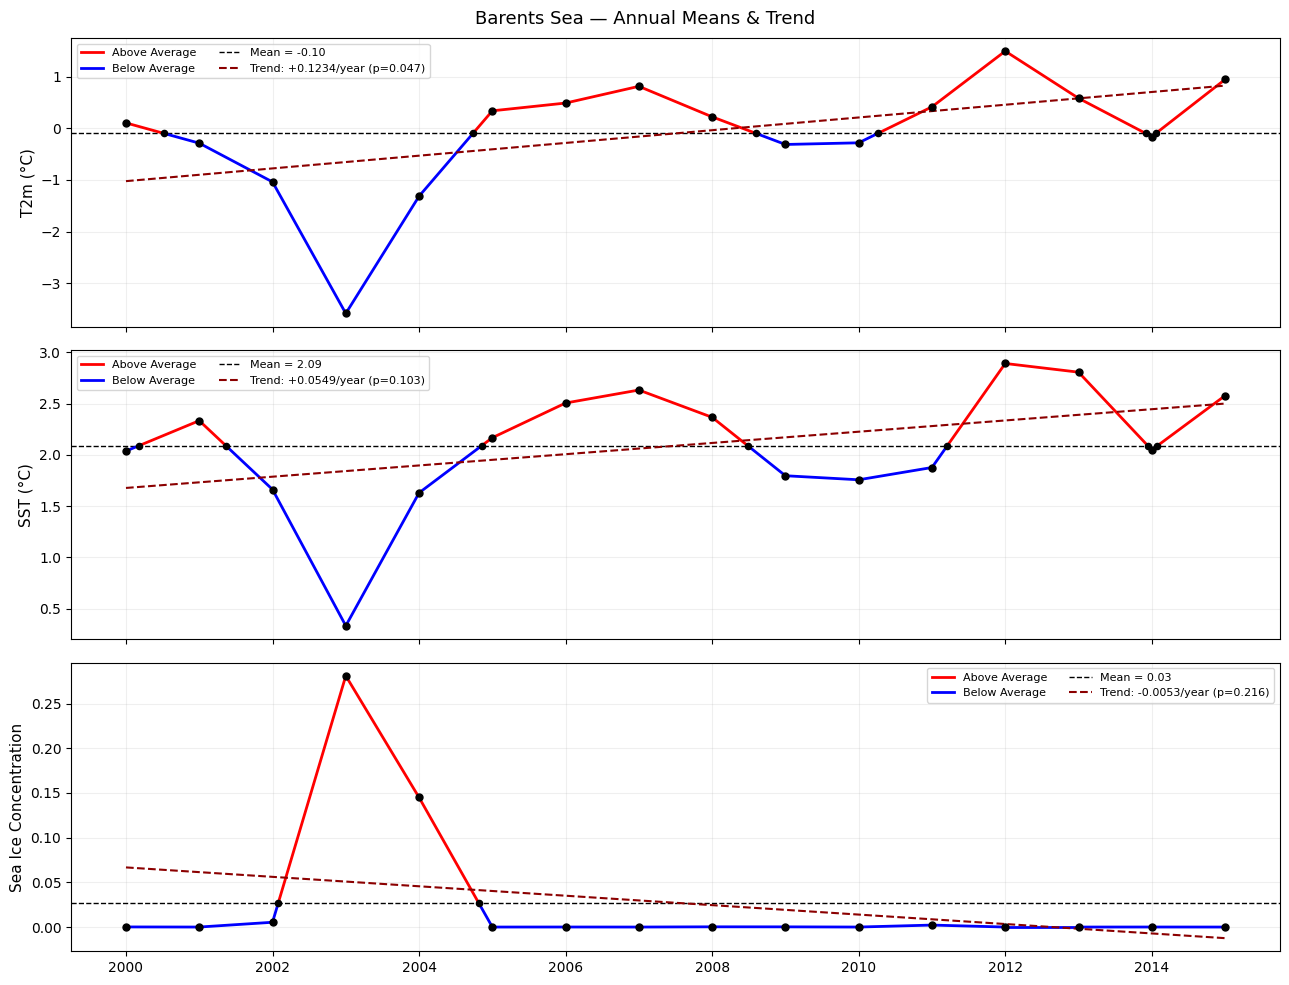

In [ ]:
# 3: Yıllık ortalamalar + trend
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (col, label, color) in zip(axes, vars_plot):
    yearly = df.groupby('year')[col].mean()
    grand_mean = yearly.mean()
    x = yearly.index.values.astype(float)
    y = yearly.values

    ax.axhline(grand_mean, color='black', ls='--', lw=1,
               label=f'Mean = {grand_mean:.2f}')

    for i in range(len(x) - 1):
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]

        # Segment mean çizgisini geçiyor mu?
        if (y0 - grand_mean) * (y1 - grand_mean) < 0:
            # Kesişim noktasını bul
            t = (grand_mean - y0) / (y1 - y0)
            x_cross = x0 + t * (x1 - x0)

            # İlk parça
            c0 = 'red' if y0 >= grand_mean else 'blue'
            ax.plot([x0, x_cross], [y0, grand_mean], color=c0, lw=2)

            # İkinci parça
            c1 = 'red' if y1 >= grand_mean else 'blue'
            ax.plot([x_cross, x1], [grand_mean, y1], color=c1, lw=2)

            # Kesişim noktasına nokta at
            ax.scatter([x_cross], [grand_mean], color='black', s=20, zorder=5)
        else:
            c = 'red' if (y0 + y1) / 2 >= grand_mean else 'blue'
            ax.plot([x0, x1], [y0, y1], color=c, lw=2)

    ax.scatter(x, y, color='black', s=25, zorder=5)

    years_num = yearly.index.values
    slope, intercept, r, p, _ = stats.linregress(years_num, yearly.values)
    ax.plot(years_num, slope * years_num + intercept, color='darkred',
            lw=1.5, ls='--', label=f'Trend: {slope:+.4f}/year (p={p:.3f})')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red',     lw=2, label='Above Average'),
        Line2D([0], [0], color='blue',    lw=2, label='Below Average'),
        Line2D([0], [0], color='black',   lw=1, ls='--', label=f'Mean = {grand_mean:.2f}'),
        Line2D([0], [0], color='darkred', lw=1.5, ls='--', label=f'Trend: {slope:+.4f}/year (p={p:.3f})'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, ncol=2)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(alpha=0.2)

plt.suptitle('Barents Sea — Annual Means & Trend', fontsize=13)
plt.tight_layout()
plt.savefig('01b_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

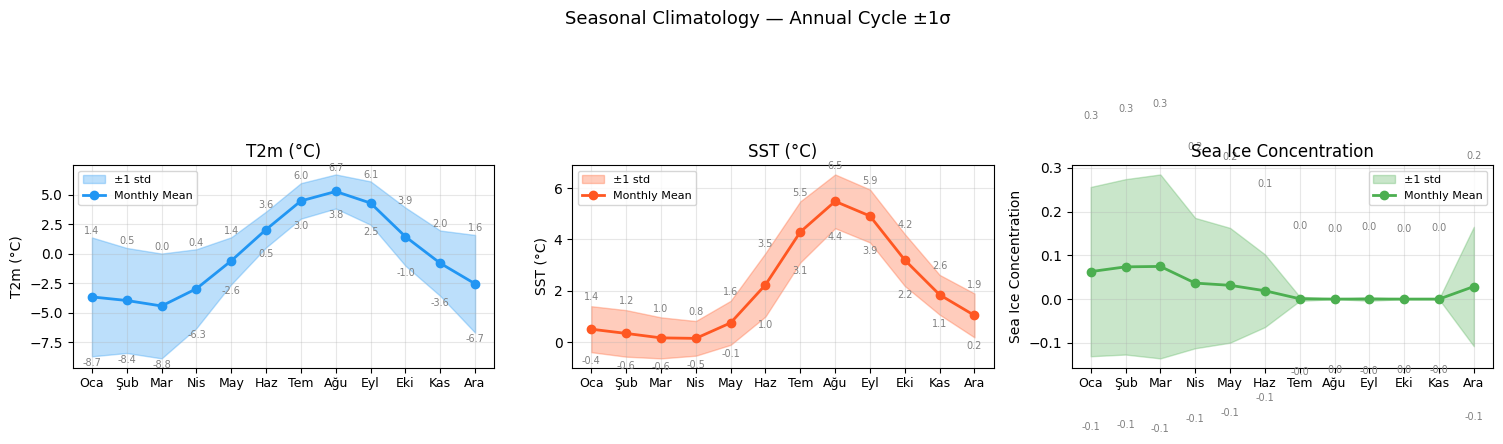

In [ ]:
# 4: Mevsimsel klimatoloji
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label, color) in zip(axes, vars_plot):
    mm = df.groupby('month')[col].mean()
    ms = df.groupby('month')[col].std()
    upper = mm + ms
    lower = mm - ms

    ax.fill_between(mm.index, lower, upper,
                    alpha=0.3, color=color, label='±1 std')
    ax.plot(mm.index, mm.values, 'o-', color=color, lw=2, ms=6,
            label='Monthly Mean')

    for m in mm.index:
        ax.text(m, upper[m] + 0.15, f'{upper[m]:.1f}',
                ha='center', va='bottom', fontsize=7, color='gray')
        ax.text(m, lower[m] - 0.15, f'{lower[m]:.1f}',
                ha='center', va='top', fontsize=7, color='gray')

    ax.set_xticks(range(1,13))
    ax.set_xticklabels(ay_isimleri, fontsize=9)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Seasonal Climatology — Annual Cycle ±1σ', fontsize=13)
plt.tight_layout()
plt.savefig('01c_climatology.png', dpi=150, bbox_inches='tight')
plt.show()

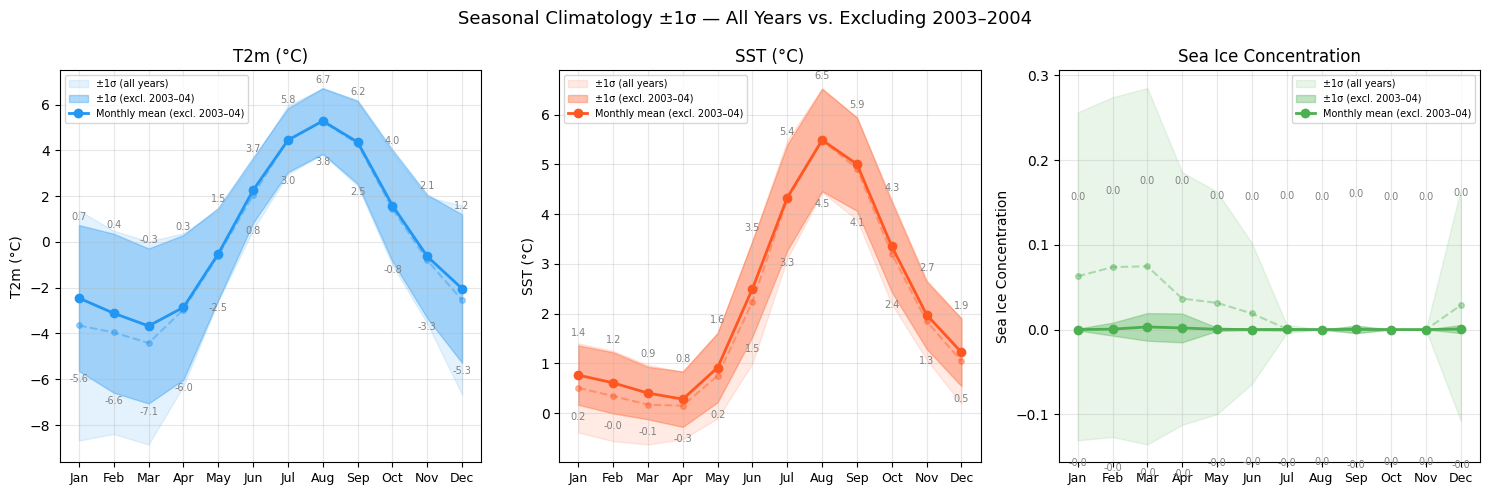

In [ ]:
# 4-1: Mevsimsel klimatoloji (2003-2004 hariç vs tüm veri)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_filtered = df[~df['year'].isin([2003, 2004])]

ay_isimleri = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, (col, label, color) in zip(axes, vars_plot):
    # 2003-2004 hariç
    mm = df_filtered.groupby('month')[col].mean()
    ms = df_filtered.groupby('month')[col].std()
    upper = mm + ms
    lower = mm - ms

    # Tüm veri
    mm_all = df.groupby('month')[col].mean()
    ms_all = df.groupby('month')[col].std()
    upper_all = mm_all + ms_all
    lower_all = mm_all - ms_all

    # Tüm veri bandı (arka planda, soluk)
    ax.fill_between(mm_all.index, lower_all, upper_all,
                    alpha=0.12, color=color, label='±1σ (all years)')
    ax.plot(mm_all.index, mm_all.values, 'o--', color=color,
            lw=1.5, ms=4, alpha=0.4)

    # 2003-2004 hariç bandı (ön planda)
    ax.fill_between(mm.index, lower, upper,
                    alpha=0.35, color=color, label='±1σ (excl. 2003–04)')
    ax.plot(mm.index, mm.values, 'o-', color=color, lw=2, ms=6,
            label='Monthly mean (excl. 2003–04)')

    # Üst ve alt değerleri yaz (hariç tutulan için)
    for m in mm.index:
        ax.text(m, upper[m] + 0.15, f'{upper[m]:.1f}',
                ha='center', va='bottom', fontsize=7, color='gray')
        ax.text(m, lower[m] - 0.15, f'{lower[m]:.1f}',
                ha='center', va='top', fontsize=7, color='gray')

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(ay_isimleri, fontsize=9)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Seasonal Climatology ±1σ — All Years vs. Excluding 2003–2004', fontsize=13)
plt.tight_layout()
plt.savefig('01c_climatology.png', dpi=150, bbox_inches='tight')
plt.show()

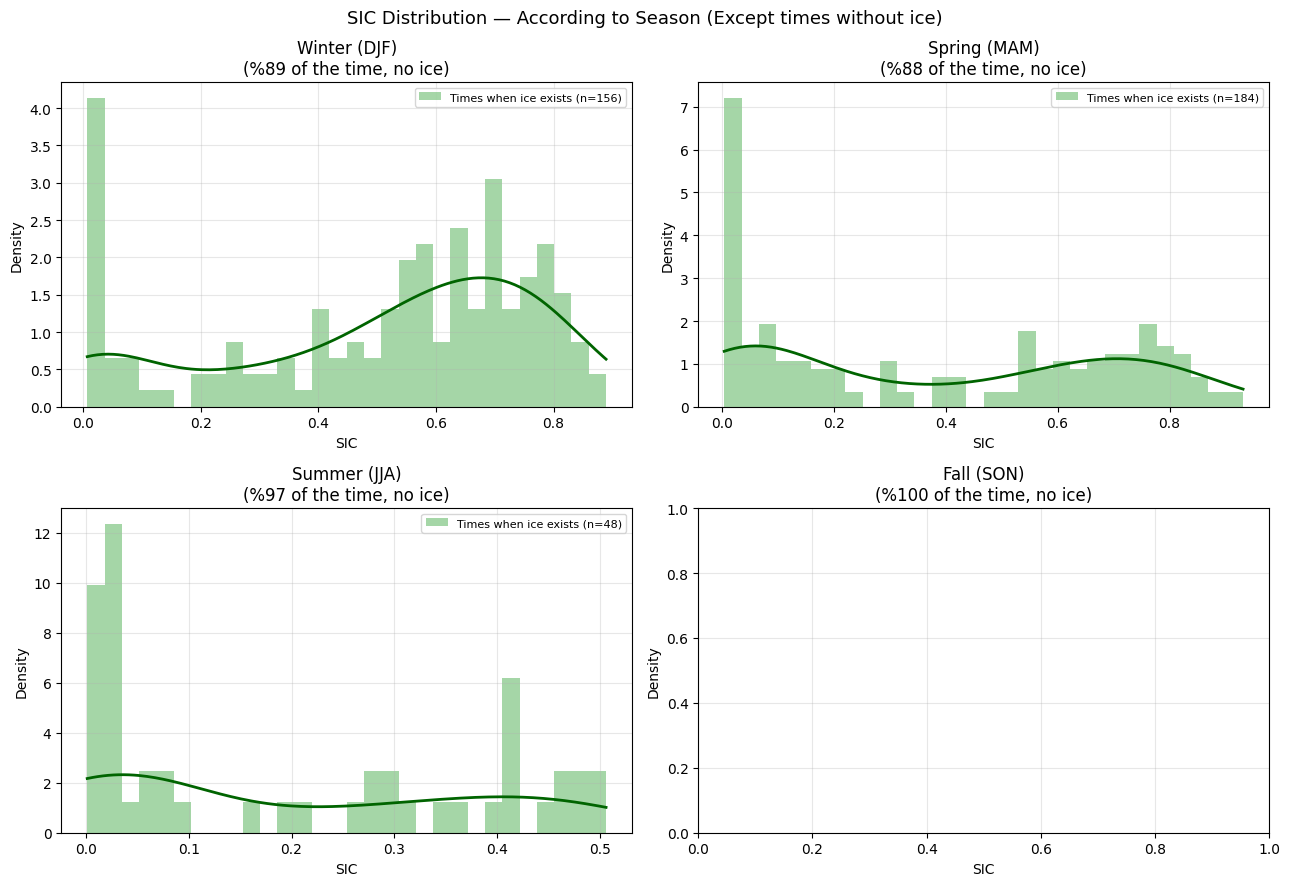

In [ ]:
# 5: SIC mevsimsel dağılım (buzsuz zamanlar hariç)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

mevsimler = {
    'Winter (DJF)':      [12, 1, 2],
    'Spring (MAM)': [3, 4, 5],
    'Summer (JJA)':      [6, 7, 8],
    'Fall (SON)':  [9, 10, 11]
}

for ax, (isim, aylar) in zip(axes.flat, mevsimler.items()):
    data = df[df['month'].isin(aylar)]['sic'].dropna()
    data_buz = data[data > 0.001]
    pct_sifir = (data <= 0.001).sum() / len(data) * 100

    if len(data_buz) > 5:
        ax.hist(data_buz, bins=30, density=True,
                alpha=0.5, color='#4CAF50',
                label=f'Times when ice exists (n={len(data_buz)})')
        kde_x = np.linspace(data_buz.min(), data_buz.max(), 200)
        ax.plot(kde_x, stats.gaussian_kde(data_buz)(kde_x),
                'darkgreen', lw=2)

    ax.set_title(f'{isim}\n(%{pct_sifir:.0f} of the time, no ice)')
    ax.set_xlabel('SIC')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.3)
    if len(data_buz) > 5:
        ax.legend(fontsize=8)

plt.suptitle('SIC Distribution — According to Season (Except times without ice)', fontsize=13)
plt.tight_layout()
plt.savefig('01d_sic_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

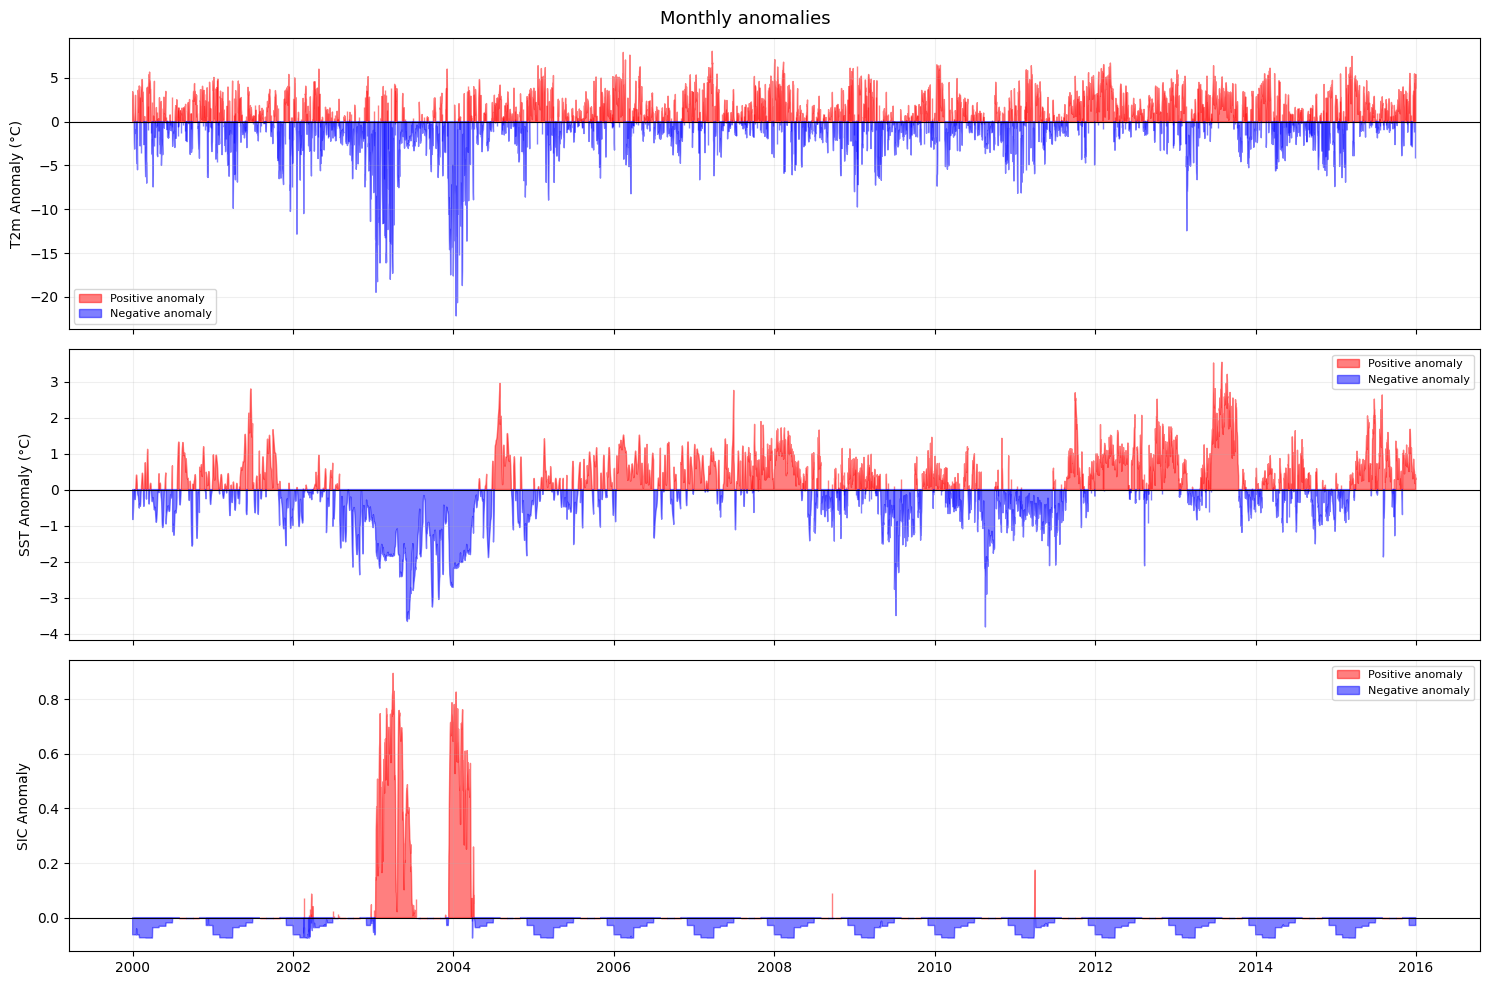

In [ ]:
# 6: Anomali zaman serisi
climatology = df.groupby('month')[['t2m','sst','sic']].mean()
df_anom = df.copy()
for col in ['t2m','sst','sic']:
    df_anom[col+'_anom'] = df[col] - df['month'].map(climatology[col])

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
anom_vars = [('t2m_anom', 'T2m Anomaly (°C)',    '#2196F3'),
             ('sst_anom', 'SST Anomaly (°C)',    '#FF5722'),
             ('sic_anom', 'SIC Anomaly',         '#4CAF50')]

for ax, (col, label, color) in zip(axes, anom_vars):
    ax.fill_between(df_anom.index, df_anom[col], 0,
                    where=df_anom[col] >= 0,
                    color='red', alpha=0.5, label='Positive anomaly')
    ax.fill_between(df_anom.index, df_anom[col], 0,
                    where=df_anom[col] < 0,
                    color='blue', alpha=0.5, label='Negative anomaly')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Monthly anomalies', fontsize=13)
plt.tight_layout()
plt.savefig('02b_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

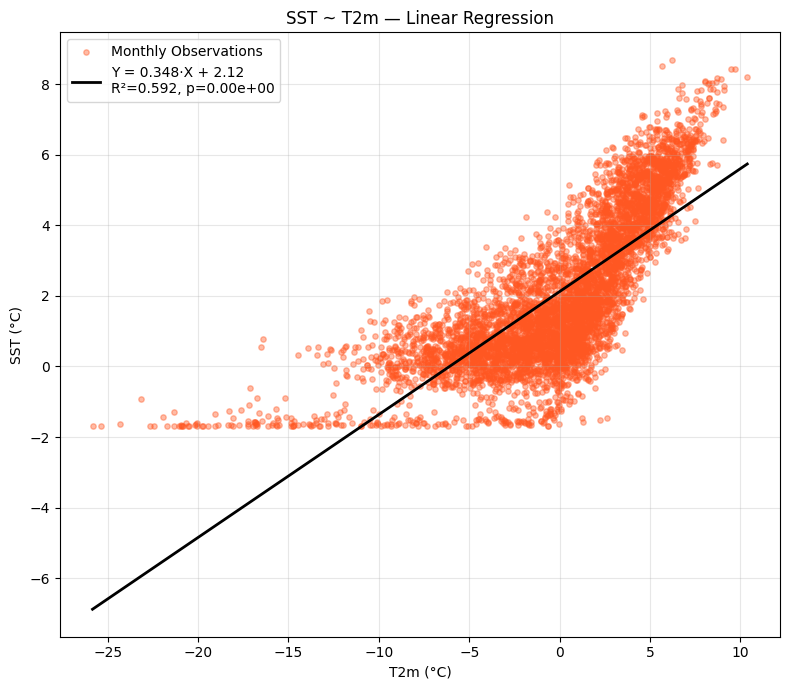

In [ ]:
# 7: SST - T2m regresyon
mask = ~(np.isnan(df['sst']) | np.isnan(df['t2m']))
x_v  = df.loc[mask, 't2m'].values
y_v  = df.loc[mask, 'sst'].values

slope_r, intercept_r, r_r, p_r, _ = stats.linregress(x_v, y_v)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(x_v, y_v, alpha=0.4, s=15, color='#FF5722',
           label='Monthly Observations')
x_line = np.linspace(x_v.min(), x_v.max(), 100)
ax.plot(x_line, slope_r*x_line + intercept_r, 'k-', lw=2,
        label=f'Y = {slope_r:.3f}·X + {intercept_r:.2f}\nR²={r_r**2:.3f}, p={p_r:.2e}')
ax.set_xlabel('T2m (°C)')
ax.set_ylabel('SST (°C)')
ax.set_title('SST ~ T2m — Linear Regression')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('04b_regression.png', dpi=150, bbox_inches='tight')
plt.show()

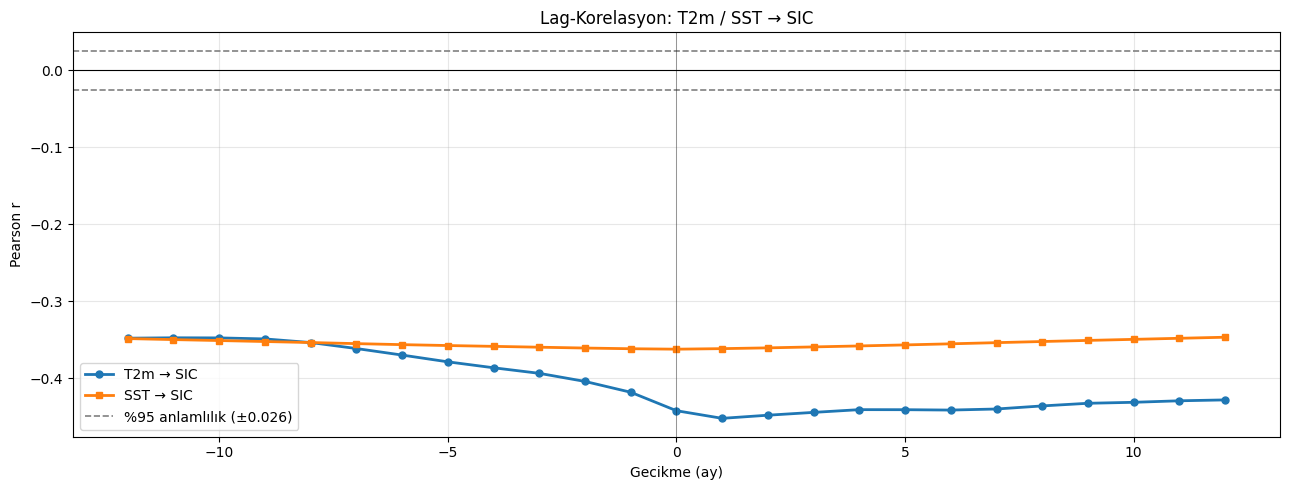

Max T2m-SIC: r=-0.452 @ lag=1 ay
Max SST-SIC: r=-0.362  @ lag=0 ay


In [ ]:
# 8: Lag-korelasyon
max_lag = 12

def lag_corr(x, y, lag):
    if lag > 0:   return stats.pearsonr(x[:-lag], y[lag:])[0]
    elif lag < 0: return stats.pearsonr(x[-lag:], y[:lag])[0]
    else:         return stats.pearsonr(x, y)[0]

lags    = list(range(-max_lag, max_lag+1))
sic_a   = df['sic'].values
t2m_a   = df['t2m'].values
sst_a   = df['sst'].values

r_t2m = [lag_corr(t2m_a, sic_a, l) for l in lags]
r_sst  = [lag_corr(sst_a,  sic_a, l) for l in lags]

n     = len(df)
t_c   = stats.t.ppf(0.975, n-2)
r_crit = t_c / np.sqrt(t_c**2 + n - 2)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(lags, r_t2m, 'o-', lw=2, ms=5, label='T2m → SIC')
ax.plot(lags, r_sst,  's-', lw=2, ms=5, label='SST → SIC')
ax.axhline( r_crit, color='gray', ls='--', lw=1.2,
            label=f'%95 anlamlılık (±{r_crit:.3f})')
ax.axhline(-r_crit, color='gray', ls='--', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('Gecikme (ay)')
ax.set_ylabel('Pearson r')
ax.set_title('Lag-Korelasyon: T2m / SST → SIC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05a_lag_corr.png', dpi=150, bbox_inches='tight')
plt.show()

idx_t2m = np.argmax(np.abs(r_t2m))
idx_sst  = np.argmax(np.abs(r_sst))
print(f"Max T2m-SIC: r={r_t2m[idx_t2m]:.3f} @ lag={lags[idx_t2m]} ay")
print(f"Max SST-SIC: r={r_sst[idx_sst]:.3f}  @ lag={lags[idx_sst]} ay")

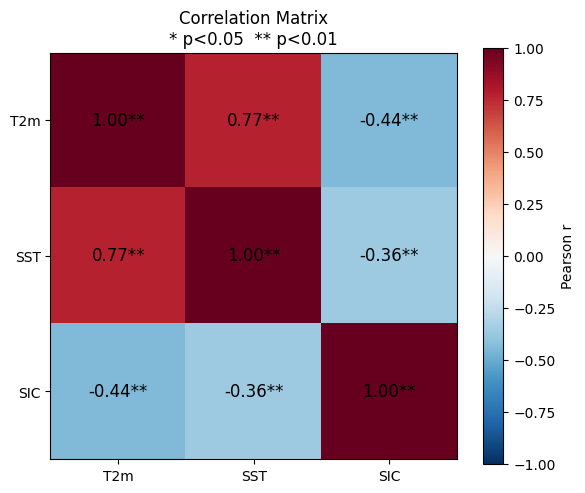

In [ ]:
# 9: Korelasyon ısı haritası
from matplotlib.colors import TwoSlopeNorm

data_c = df[['t2m','sst','sic']].dropna()
lbls   = ['T2m','SST','SIC']
n_v    = len(lbls)
r_mat  = np.zeros((n_v, n_v))
p_mat  = np.ones((n_v, n_v))

for i in range(n_v):
    for j in range(n_v):
        r_mat[i,j], p_mat[i,j] = stats.pearsonr(
            data_c.iloc[:,i], data_c.iloc[:,j])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r_mat, cmap='RdBu_r',
               norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(n_v)); ax.set_yticks(range(n_v))
ax.set_xticklabels(lbls);  ax.set_yticklabels(lbls)

for i in range(n_v):
    for j in range(n_v):
        sig = '**' if p_mat[i,j]<0.01 else ('*' if p_mat[i,j]<0.05 else '')
        ax.text(j, i, f'{r_mat[i,j]:.2f}{sig}',
                ha='center', va='center', fontsize=12)

ax.set_title('Correlation Matrix\n* p<0.05  ** p<0.01')
plt.tight_layout()
plt.savefig('05b_corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

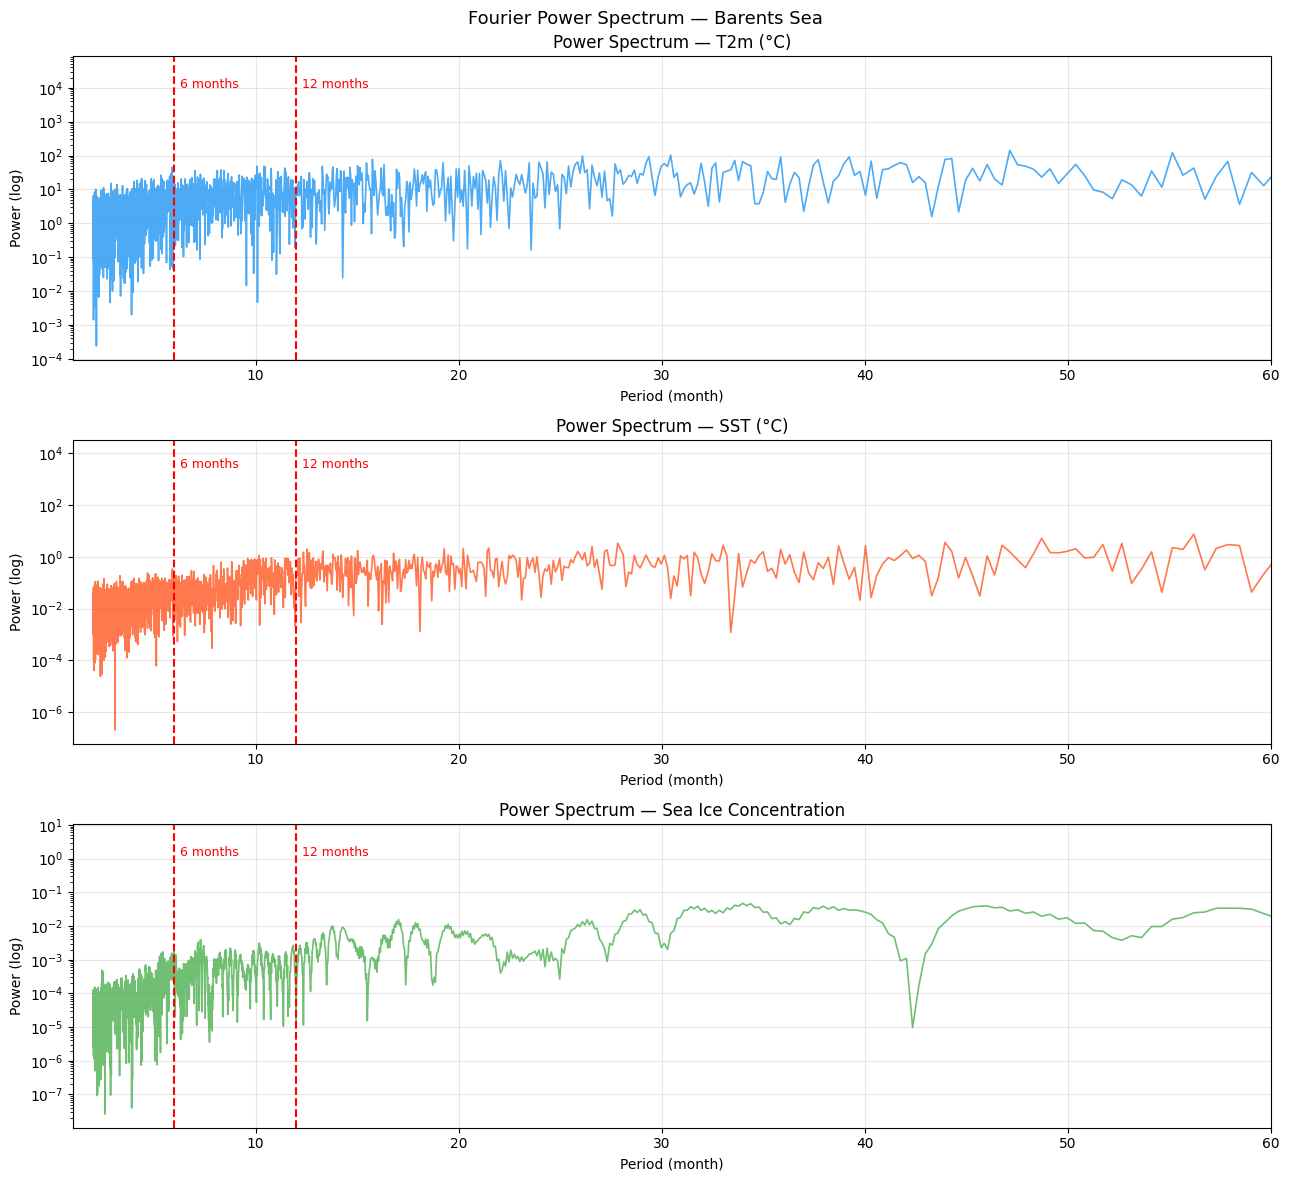

In [ ]:
# 10: Power spektrum
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for ax, (col, label, color) in zip(axes, vars_plot):
    s = df[col].fillna(df[col].mean()).values
    s = s - s.mean()
    N = len(s)

    freqs   = np.fft.rfftfreq(N, d=1)
    power   = (np.abs(np.fft.rfft(s))**2) / N
    periods = np.where(freqs[1:] > 0, 1/freqs[1:], np.inf)

    ax.semilogy(periods, power[1:], color=color, lw=1.2, alpha=0.8)
    for p_val, p_lbl in [(12,'12 months'), (6,'6 months')]:
        ax.axvline(p_val, color='red', ls='--', lw=1.5)
        ax.text(p_val+0.3, power[1:].max()*0.3, p_lbl,
                color='red', fontsize=9)
    ax.set_xlim(1, 60)
    ax.set_xlabel('Period (month)')
    ax.set_ylabel('Power (log)')
    ax.set_title(f'Power Spectrum — {label}')
    ax.grid(alpha=0.3)

plt.suptitle('Fourier Power Spectrum — Barents Sea', fontsize=13)
plt.tight_layout()
plt.savefig('06a_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

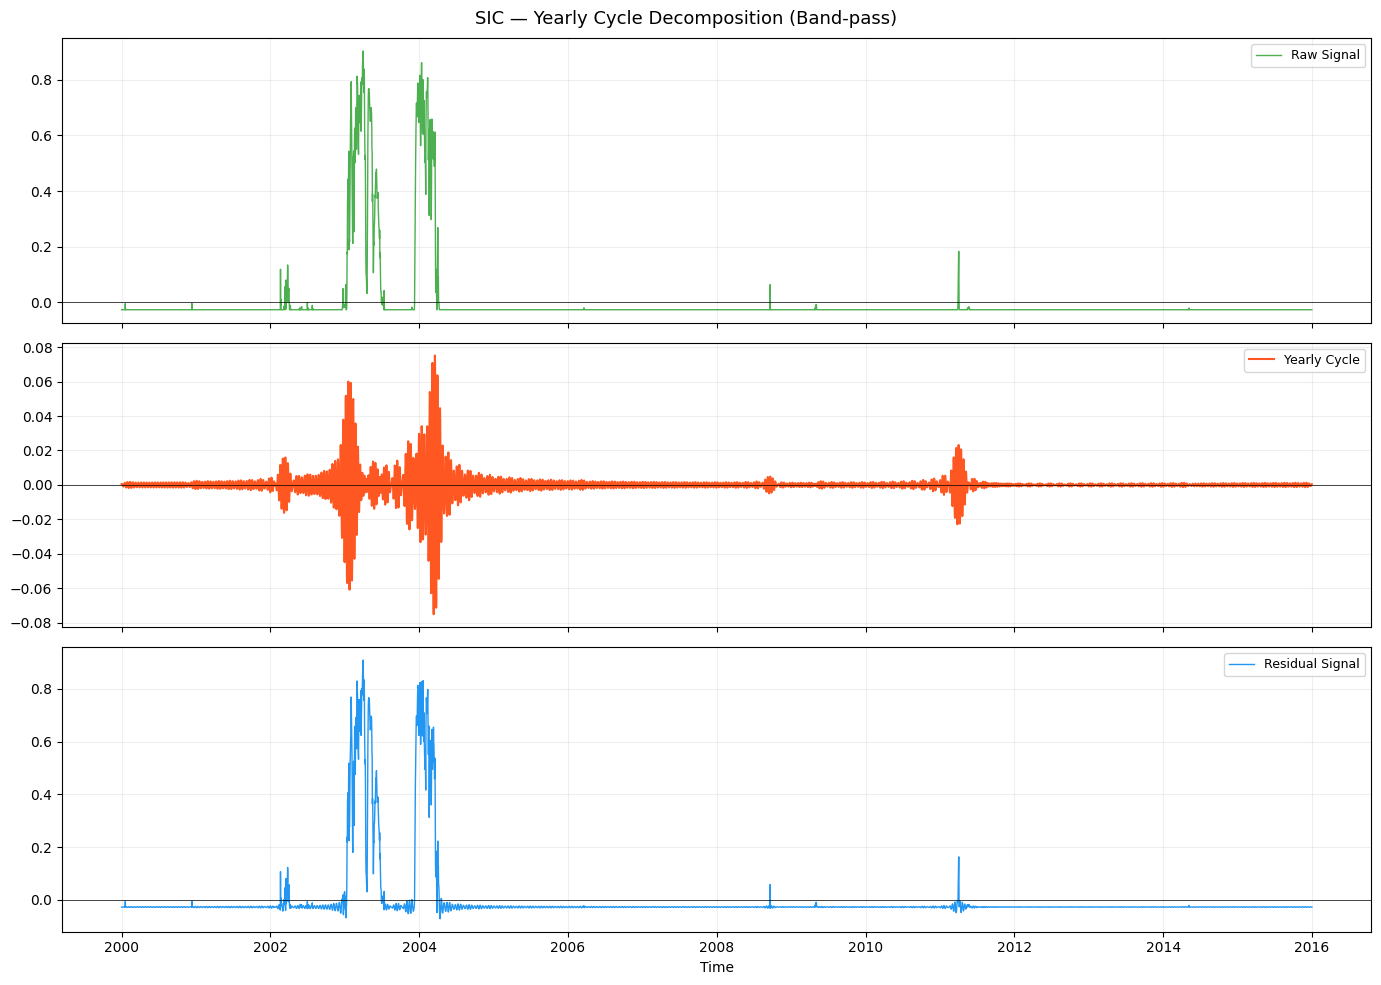

In [ ]:
# 11: Hann pencereli yıllık siklus ayrıştırma
s = df['sic'].fillna(df['sic'].mean()).values
s = s - s.mean()
N = len(s)

freqs     = np.fft.rfftfreq(N, d=1)
fft_vals  = np.fft.rfft(s)

# (band-pass)
fft_filt  = fft_vals.copy()
fft_filt[np.abs(freqs - 1/12) >= 0.01] = 0
annual    = np.fft.irfft(fft_filt, N)
residual  = s - annual

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df.index, s,        color='#4CAF50', lw=1,   label='Raw Signal')
axes[1].plot(df.index, annual,   color='#FF5722', lw=1.5, label='Yearly Cycle')
axes[2].plot(df.index, residual, color='#2196F3', lw=1,   label='Residual Signal')

for ax in axes:
    ax.axhline(0, color='black', lw=0.5)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
axes[2].set_xlabel('Time')

plt.suptitle('SIC — Yearly Cycle Decomposition (Band-pass)', fontsize=13)
plt.tight_layout()
plt.savefig('06b_decompose.png', dpi=150, bbox_inches='tight')
plt.show()